In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import gtfs_functions
from matplotlib.animation import FuncAnimation
from shapely.geometry import LineString, MultiPoint
from zipfile import ZipFile
import os

# Overwriting functions from *gtfs_functions* module
The module *gtfs_functions* had problems with the *shapes.txt*. I modified some of these functions to get rid of these issues. Most of the code below is source code from gtfs_functions with some minor changes by me.

## aux - Additional functions

In [296]:
import numpy as np
import pandas as pd
from zipfile import ZipFile
import os
import logging
import geopandas as gpd
import requests
import io
import pendulum as pl
import hashlib
from shapely.geometry import LineString, MultiPoint
from itertools import permutations, chain
from shapely import distance
#from h3 import latlng_to_cell, grid_ring
from time import time
import boto3
import sys


def add_runtime(st):
    # Get the runtime between stops
    logging.info("adding runtime")
    st.sort_values(by=["trip_id", "stop_sequence"], inplace=True, ascending=True)
    c = st.trip_id == st.trip_id.shift(-1)
    st.loc[c, "runtime_sec"] = st.arrival_time.shift(-1)[c] - st.arrival_time[c]
    st["end_stop_id"] = st.stop_id.shift(-1)

    return st


def add_distance(
    stop_times,
    segments_gdf,
    seg_cols=[
        "shape_id",
        "route_id",
        "direction_id",
        "stop_sequence",
        "segment_id",
        "segment_name",
        "start_stop_id",
        "end_stop_id",
        "start_stop_name",
        "end_stop_name",
        "distance_m",
        "geometry",
    ],
    st_cols=[
        "shape_id",
        "route_id",
        "route_name",
        "direction_id",
        "stop_sequence",
        "stop_id",
        "end_stop_id",
        "runtime_sec",
        "arrival_time",
        "departure_time",
    ],
):
    logging.info("adding distance in meters")
    st = stop_times[st_cols]
    st.rename(columns={"stop_id": "start_stop_id"}, inplace=True)

    # Merge with segments_gdf to get the distance
    dist = pd.merge(st, segments_gdf[seg_cols], how="left")
    dist = gpd.GeoDataFrame(data=dist, geometry=dist.geometry, crs="EPSG:4326")

    return dist


def add_speed(speeds):
    # Calculate the speed for runtimes != 0
    logging.info("calculating speed in km/h")
    c = speeds.runtime_sec != 0
    speeds.loc[c, "speed_kmh"] = round(speeds[c].distance_m / speeds[c].runtime_sec * 3.6)

    # Assign average speed to those with runtimes==0
    speeds.loc[~c, "speed_kmh"] = speeds[c].speed_kmh.mean()

    # Remove null values
    speeds = speeds.loc[~speeds.speed_kmh.isnull()]

    return speeds


def fix_outliers(speeds):
    # Calculate average speed to modify outliers
    logging.info("fixing outliers")
    avg_speed_route = speeds.pivot_table(
        "speed_kmh", index=["route_id", "direction_id", "window"], aggfunc="mean"
    ).reset_index()

    avg_speed_route.rename(columns={"speed_kmh": "avg_route_speed_kmh"}, inplace=True)

    # Assign average speed to outliers
    speeds = pd.merge(speeds, avg_speed_route, how="left")
    out_c = speeds.speed_kmh > 120
    speeds.loc[out_c, "speed_kmh"] = speeds.loc[out_c, "avg_route_speed_kmh"]

    # Get the columns in the right format
    speeds["avg_route_speed_kmh"] = round(speeds.avg_route_speed_kmh, 1)

    return speeds


def aggregate_speed(speeds, segments_gdf):
    # Get the average per route, direction, segment and time of day
    logging.info("aggregating speed by segment and window")
    speeds_agg = speeds.pivot_table(
        ["speed_kmh", "runtime_sec", "avg_route_speed_kmh"],
        index=["route_name", "direction_id", "segment_id", "window"],
        aggfunc="mean",
    ).reset_index()

    # Format the merge columns correctly
    speeds_agg["direction_id"] = speeds_agg.direction_id.astype(int)
    segments_gdf["direction_id"] = segments_gdf.direction_id.astype(int)

    # Add geometries to segments
    data = (
        pd.merge(
            speeds_agg,
            segments_gdf,
            left_on=["route_name", "direction_id", "segment_id"],
            right_on=["route_name", "direction_id", "segment_id"],
            how="left",
        )
        .reset_index(drop=True)
        .sort_values(by=["route_id", "direction_id", "window", "stop_sequence"], ascending=True)
    )

    ordered_cols = [
        "route_id",
        "route_name",
        "direction_id",
        "segment_id",
        "window",
        "speed_kmh",
        "avg_route_speed_kmh",
        "stop_sequence",
        "segment_name",
        "start_stop_name",
        "end_stop_name",
        "start_stop_id",
        "end_stop_id",
        "shape_id",
        "runtime_sec",
        "distance_m",
        "geometry",
    ]

    return data[ordered_cols]


def get_all_lines_speed(speeds, segments_gdf):
    # Get the average per segment and time of day
    # Then add it to the rest of the data
    all_lines = speeds.pivot_table(
        ["speed_kmh", "runtime_sec", "avg_route_speed_kmh"],
        index=["segment_id", "window"],
        aggfunc="mean",
    ).reset_index()

    data_all_lines = (
        pd.merge(
            all_lines,
            segments_gdf.drop_duplicates(subset=["segment_id"]),
            left_on=["segment_id"],
            right_on=["segment_id"],
            how="left",
        )
        .reset_index(drop=True)
        .sort_values(by=["direction_id", "window", "stop_sequence"], ascending=True)
    )

    data_all_lines["route_id"] = "ALL_LINES"
    data_all_lines["route_name"] = "All lines"
    data_all_lines["direction_id"] = "NA"

    return data_all_lines


def add_all_lines_speed(data, speeds, segments_gdf):
    # Get data for all lines
    data_all_lines = get_all_lines_speed(speeds, segments_gdf)

    # Add it to the data we already had
    data_complete = pd.concat([data, data_all_lines])

    # Clean data
    data_complete = data_complete[~data_complete.route_name.isnull()].reset_index(drop=True)

    # Get the columns in the right format
    data_complete["speed_kmh"] = round(data_complete.speed_kmh, 1)

    cols = [
        "route_id",
        "route_name",
        "direction_id",
        "segment_name",
        "window",
        "speed_kmh",
        "segment_id",
        "start_stop_id",
        "start_stop_name",
        "end_stop_id",
        "end_stop_name",
        "distance_m",
        "stop_sequence",
        "shape_id",
        "runtime_sec",
        "geometry",
    ]

    return data_complete


def add_free_flow(speeds, data_complete):
    # Calculate max speed per segment to have a free_flow reference
    max_speed_segment = speeds.pivot_table("speed_kmh", index="segment_name", aggfunc="max")

    max_speed_segment.rename(columns={"speed_kmh": "segment_max_speed_kmh"}, inplace=True)

    # Assign max speeds to each segment
    data_complete = pd.merge(
        data_complete,
        max_speed_segment,
        left_on=["segment_name"],
        right_index=True,
        how="left",
    )

    order_cols = [
        "route_name",
        "direction_id",
        "window",
        "segment_name",
        "stop_sequence",
        "speed_kmh",
        "avg_route_speed_kmh",
        "segment_max_speed_kmh",
        "route_id",
        "segment_id",
        "start_stop_name",
        "end_stop_name",
        "start_stop_id",
        "end_stop_id",
        "shape_id",
        "runtime_sec",
        "distance_m",
        "geometry",
    ]

    return data_complete


def add_all_lines(line_frequencies, segments_gdf, labels, cutoffs):

    logging.info("adding data for all lines.")

    # Calculate sum of trips per segment with all lines
    all_lines = line_frequencies.pivot_table(["ntrips"], index=["segment_id", "window"], aggfunc="sum").reset_index()

    sort_these = ["direction_id", "window", "stop_sequence"]

    data_all_lines = (
        pd.merge(
            all_lines,
            segments_gdf.drop_duplicates(subset=["segment_id"]),
            left_on=["segment_id"],
            right_on=["segment_id"],
            how="left",
        )
        .reset_index()
        .sort_values(by=sort_these, ascending=True)
    )

    data_all_lines.drop(["index"], axis=1, inplace=True)
    data_all_lines["route_id"] = "ALL_LINES"
    data_all_lines["route_name"] = "All lines"
    data_all_lines["direction_id"] = "NA"

    # Add frequency for all lines
    start_time = data_all_lines.window.apply(lambda x: cutoffs[labels.index(x)])
    end_time = data_all_lines.window.apply(lambda x: cutoffs[labels.index(x) + 1])

    data_all_lines["min_per_trip"] = ((end_time - start_time) * 60 / data_all_lines.ntrips).astype(int)

    # Append data for all lines to the input df
    data_complete = pd.concat([line_frequencies, data_all_lines]).reset_index(drop=True)

    return data_complete


def fix_departure_time(times_to_fix):
    """
    Reassigns departure time to trips that start after the hour 24
    for the to fit in a 0-24 hour range
    Input:
        - times_to_fix: np.array of integers with seconds past from midnight.
    """

    next_day = times_to_fix >= 24 * 3600
    times_to_fix[next_day] = times_to_fix[next_day] - 24 * 3600

    return times_to_fix


def label_creation(cutoffs):
    """
    Creates the labels of the time windows.
    Input:
        - cutoffs: list of floats or int.
    Output:
        - labels: list of strings.

    Example:
    label_creation(cutoffs=[0, 10, 15.5, 25]) --> [0:00, 10:00, 15:30, 25:00]
    """
    labels = []
    if max(cutoffs) <= 24:
        for w in cutoffs:
            if float(w).is_integer():
                label = str(w) + ":00"
            else:
                n = math.modf(w)
                label = str(int(n[1])) + ":" + str(int(n[0] * 60))
            labels.append(label)
    else:
        labels = []
        for w in cutoffs:
            if float(w).is_integer():
                if w > 24:
                    w1 = w - 24
                    label = str(w1) + ":00"
                else:
                    label = str(w) + ":00"
                labels.append(label)
            else:
                if w > 24:
                    w1 = w - 24
                    n = math.modf(w1)
                    label = str(int(n[1])) + ":" + str(int(n[0] * 60))
                else:
                    n = math.modf(w)
                    label = str(int(n[1])) + ":" + str(int(n[0] * 60))
                labels.append(label)

    labels = [labels[i] + "-" + labels[i + 1] for i in range(0, len(labels) - 1)]

    return labels


def window_creation(stop_times, cutoffs):
    "Adds the time time window and labels to stop_times"

    # If the cutoffs are withing 0 and 24 hours, let's make sure
    # the times of the GTFS fit this time period
    if max(cutoffs) <= 24:
        stop_times["departure_time"] = fix_departure_time(stop_times.departure_time.values)
        stop_times["arrival_time"] = fix_departure_time(stop_times.arrival_time.values)

    # Create the labels for the cutoffs
    labels = label_creation(cutoffs)

    # Get departure time as hour and a fraction
    departure_time = stop_times.departure_time / 3600

    # Put each trip in the right window
    stop_times["window"] = pd.cut(departure_time, bins=cutoffs, right=False, labels=labels)
    stop_times = stop_times.loc[~stop_times.window.isnull()]

    stop_times["window"] = stop_times.window.astype(str)

    return stop_times


def seconds_since_midnight(times_string):
    """
    Transforms a series of time strings of the form "10:00:10"
    to an integer that represents the seconds since midnight.
    """

    vals = times_string.split(":")
    seconds = 0

    for p, v in enumerate(vals):
        seconds += int(v) * (3600 / (60**p))

    return seconds


def add_frequency(
    stop_times,
    labels,
    index_="stop_id",
    col="window",
    cutoffs=[0, 6, 9, 15, 19, 22, 24],
):

    if isinstance(index_, list):
        index_list = index_ + ["direction_id", col]
    elif isinstance(index_, str):
        index_list = [index_, "direction_id", col]

    # Some gtfs feeds only contain direction_id 0, use that as default
    trips_agg = stop_times.pivot_table("trip_id", index=index_list, aggfunc="count").reset_index()

    # direction_id is optional, as it is not needed to determine trip frequencies
    # However, if direction_id is NaN, pivot_table will return an empty DataFrame.
    # Therefore, use a sensible default if direction id is not known.
    # Some gtfs feeds only contain direction_id 0, use that as default
    trips_agg.rename(columns={"trip_id": "ntrips"}, inplace=True)

    start_time = trips_agg.window.apply(lambda x: cutoffs[labels.index(x)])
    end_time = trips_agg.window.apply(lambda x: cutoffs[labels.index(x) + 1])

    trips_agg["min_per_trip"] = ((end_time - start_time) * 60 / trips_agg.ntrips).astype(int)

    return trips_agg


def add_route_name(data, routes):
    # Add the route name
    routes["route_name"] = ""

    def check_null(col):
        # Check for null values
        check = (
            routes[col].isnull().unique()[0] | (routes[col] == np.nan).unique()[0] | (routes[col] == "nan").unique()[0]
        )

        return check

    if check_null("route_short_name"):
        routes["route_name"] = routes.route_long_name
    elif check_null("route_long_name"):
        routes["route_name"] = routes.route_short_name
    else:
        routes["route_name"] = routes.route_short_name.astype(str) + " " + routes.route_long_name.astype(str)

    data = pd.merge(
        data,
        routes[["route_id", "route_name"]],
        left_on="route_id",
        right_on="route_id",
        how="left",
    )

    return data


def code(gdf):
    gdf.index = list(range(0, len(gdf)))
    gdf.crs = {"init": "epsg:4326"}
    lat_referece = gdf.geometry[0].coords[0][1]
    lon_reference = gdf.geometry[0].coords[0][0]

    zone = utm.from_latlon(lat_referece, lon_reference)
    # The EPSG code is 32600+zone for positive latitudes and 32700+zone for negatives.
    if lat_referece < 0:
        epsg_code = 32700 + zone[2]
    else:
        epsg_code = 32600 + zone[2]

    return epsg_code


def num_to_letters(num):
    result = ""
    while num > 0:
        num -= 1
        digit = num % 26
        result = chr(digit + 65) + result
        num //= 26
    return result

## Feed class

In [297]:
from gtfs_functions.gtfs_functions import Feed
def extract_file(file, feed):
    data_types = {"shape_id": str, "stop_id": str, "route_id": str, "trip_id": str}

    files = feed.files
    gtfs_path = feed.gtfs_path

    # check if the the zip file came from a zipped folder
    if len(files[0].split("/")) == 1:
        file_path = f"{file}.txt"
    else:
        file_path = f"{files[0].split('/')[0]}/{file}.txt"

    # Try as a local file
    try:
        if file_path in files:
            with ZipFile(gtfs_path) as myzip:
                logging.info(f'Reading "{file}.txt".')
                myzip.extract(file_path, path="/tmp")
                data = pd.read_csv(f"/tmp/{file_path}", dtype=data_types)

                os.remove(f"/tmp/{file_path}")
                return data
        else:
            return logging.info(f'File "{file}.txt" not found.')

    # Try as a URL
    except (FileNotFoundError, OSError) as e:
        logging.error(e)
        if f"{file}.txt" in files:
            r = requests.get(gtfs_path)
            with ZipFile(io.BytesIO(r.content)) as myzip:
                logging.info(f'Reading "{file}.txt".')
                myzip.extract(f"{file_path}", path="/tmp")
                data = pd.read_csv(f"/tmp/{file_path}", dtype=data_types)

                os.remove(f"/tmp/{file_path}")
                return data
        else:
            return logging.info(f'File "{file}.txt" not found.')

class Feed(Feed):
    def get_shapes(self):
        if self.geo:
            aux = extract_file("shapes", self)

            # Sort shapes by shape_pt_sequence
            aux.sort_values(["shape_id", "shape_pt_sequence"], inplace=True)
            shapes = (
                aux[["shape_id", "shape_pt_lat", "shape_pt_lon"]]
                .groupby("shape_id")
                .agg(list)
                .apply(lambda x: LineString(zip(x["shape_pt_lat"], x["shape_pt_lon"])), axis=1)
            )

            shapes = gpd.GeoDataFrame(data=shapes.index, geometry=shapes.values, crs=4326)
            shapes["shape_id"] = shapes.shape_id.astype(str)

            return shapes
        else:
            shapes = extract_file("shapes", self)
            shapes["shape_id"] = shapes.shape_id.astype(str)
            return shapes
    def get_segments(self):
        """Splits each route's shape into stop-stop LineString called segments

        Returns the segment geometry as well as additional segment information
        """
        logging.info("Getting segments...")
        stop_times = self.stop_times
        shapes = self.shapes

        req_columns = ["shape_id", "stop_sequence", "stop_id", "geometry"]
        add_columns = ["route_id", "route_name", "direction_id", "stop_name"]

        # merge stop_times and shapes to calculate cut distance and interpolated point
        df_shape_stop = (
            stop_times[req_columns + add_columns]
            .drop_duplicates()
            .merge(shapes, on="shape_id", suffixes=("_stop", "_shape"))
        )
        logging.info("Projecting stops onto shape...")
        df_shape_stop["cut_distance_stop_point"] = df_shape_stop[["geometry_stop", "geometry_shape"]].apply(
            lambda x: x['geometry_shape'].project(x['geometry_stop'], normalized=True), axis=1
        )
        logging.info("Interpolating stops onto shape...")
        df_shape_stop["projected_stop_point"] = df_shape_stop[["geometry_shape", "cut_distance_stop_point"]].apply(
            lambda x: x["geometry_shape"].interpolate(x["cut_distance_stop_point"], normalized=True), axis=1
        )

        # calculate cut distance for
        logging.info("Sorting shape points and stops...")
        df_shape = shapes[shapes.shape_id.isin(stop_times.shape_id.unique())]
        df_shape["list_of_points"] = df_shape.geometry.apply(lambda x: list(MultiPoint(x.coords).geoms))
        df_shape_exp = df_shape.explode("list_of_points")
        df_shape_exp["projected_line_points"] = df_shape_exp[["geometry", "list_of_points"]].apply(
            lambda x: x["geometry"].project(x["list_of_points"], normalized=True), axis=1
        )

        # rename both dfs to concatenate
        df_shape_stop.rename(
            {
                "projected_stop_point": "geometry",
                "cut_distance_stop_point": "normalized_distance_along_shape",
            },
            axis=1,
            inplace=True,
        )
        df_shape_stop["cut_flag"] = True

        df_shape_exp = df_shape_exp[["shape_id", "list_of_points", "projected_line_points"]]
        df_shape_exp.rename(
            {
                "list_of_points": "geometry",
                "projected_line_points": "normalized_distance_along_shape",
            },
            axis=1,
            inplace=True,
        )

        df_shape_exp["cut_flag"] = False

        # combine stops and shape points
        gdf = pd.concat([df_shape_stop, df_shape_exp], ignore_index=False)
        gdf.sort_values(["shape_id", "normalized_distance_along_shape"], inplace=True)
        gdf.reset_index(inplace=True, drop=True)

        # drop all non stops (had to combine first fto get their gdf index)
        cuts = gdf.where(gdf.cut_flag).dropna(subset="cut_flag")
        cuts = cuts.astype({"shape_id": str, "stop_sequence": int, "direction_id": int})
        cuts[["end_stop_id", "end_stop_name"]] = cuts.groupby("shape_id")[["stop_id", "stop_name"]].shift(-1)

        # Create LineString for each stop to stop
        segment_geometries = []
        for shape_id in cuts.shape_id.drop_duplicates():
            cut_idx = cuts[cuts.shape_id == shape_id].index
            for i, cut in enumerate(cut_idx[:-1]):
                segment_geometries.append(LineString(gdf.iloc[cut_idx[i] : cut_idx[i + 1] + 1].geometry))

        # create into gpd adding additional columns
        segment_df = cuts.dropna(subset="end_stop_id", axis=0)
        logging.info(f"segments_df: {len(segment_df)}, geometry: {len(segment_geometries)}")
        segment_gdf = gpd.GeoDataFrame(segment_df, geometry=segment_geometries)
        # drop irrelevant columns
        segment_gdf.drop(
            [
                "geometry_shape",
                "cut_flag",
                "normalized_distance_along_shape",
                "geometry_stop",
            ],
            axis=1,
            inplace=True,
        )
        segment_gdf.crs = "EPSG:4326"

        # Add segment length in meters
        segment_gdf["distance_m"] = segment_gdf.to_crs(code(segment_gdf)).length

        # Add segment_id and name
        segment_gdf["segment_id"] = segment_gdf.stop_id.astype(str) + " - " + segment_gdf.end_stop_id.astype(str)
        segment_gdf["segment_name"] = segment_gdf.stop_name + " - " + segment_gdf.end_stop_name

        # Order columns
        col_ordered = [
            "shape_id",
            "route_id",
            "route_name",
            "direction_id",
            "stop_sequence",
            "segment_name",
            "stop_name",
            "end_stop_name",
            "segment_id",
            "stop_id",
            "end_stop_id",
            "distance_m",
            "geometry",
        ]

        segment_gdf = segment_gdf[col_ordered]
        segment_gdf.rename(
            columns=dict(stop_name="start_stop_name", stop_id="start_stop_id"),
            inplace=True,
        )

        return segment_gdf

# Loading data and creating timetable feed of buses

In [298]:
gtfs_path = 'OtwartyWroclaw_rozklad_jazdy_GTFS_od 17.01.zip'
gtfs_path_no_zip = 'OtwartyWroclaw_rozklad_jazdy_GTFS_od 17.01'

In [299]:
feed = Feed(gtfs_path, busiest_date=False)

routes = feed.routes
trips = feed.trips
stops = feed.stops
stop_times = feed.stop_times
shapes = feed.shapes

INFO:root:Reading "routes.txt".
INFO:root:accessing trips
INFO:root:Start date is None. You should either specify a start date or set busiest_date to True.
INFO:root:Reading "trips.txt".
INFO:root:Reading "stop_times.txt".
INFO:root:_trips is defined in stop_times
INFO:root:Reading "stops.txt".
INFO:root:computing patterns
INFO:root:Reading "shapes.txt".


In [300]:
feed.segments

INFO:root:Getting segments...
INFO:root:Projecting stops onto shape...
INFO:root:Interpolating stops onto shape...
INFO:root:Sorting shape points and stops...
INFO:root:segments_df: 25858, geometry: 25858


,shape_id,route_id,route_name,direction_id,stop_sequence,segment_name,start_stop_name,end_stop_name,segment_id,start_stop_id,end_stop_id,distance_m,geometry
0,851928,122,122,0,0,MUCHOBÓR WIELKI (Roślinna) - Tyrmanda,MUCHOBÓR WIELKI (Roślinna),Tyrmanda,5635 - 2725,5635,2725,0.0,"LINESTRING (51.09594 17.04076, 51.09594 17.04076)"
1,851928,122,122,0,1,Tyrmanda - Mińska (Rondo Rotm. Pileckiego),Tyrmanda,Mińska (Rondo Rotm. Pileckiego),2725 - 5614,2725,5614,0.0,"LINESTRING (51.09594 17.04076, 51.09594 17.04076)"
2,851928,122,122,0,2,Mińska (Rondo Rotm. Pileckiego) - Rogowska (P+R),Mińska (Rondo Rotm. Pileckiego),Rogowska (P+R),5614 - 5275,5614,5275,0.0,"LINESTRING (51.09594 17.04076, 51.09594 17.04076)"
3,851928,122,122,0,3,Rogowska (P+R) - Strzegomska (krzyżówka),Rogowska (P+R),Strzegomska (krzyżówka),5275 - 5274,5275,5274,0.0,"LINESTRING (51.09594 17.04076, 51.09594 17.04076)"
4,851928,122,122,0,4,Strzegomska (krzyżówka) - Chociebuska (C. K. N...,Strzegomska (krzyżówka),Chociebuska (C. K. Nowy Pafawag),5274 - 5347,5274,5347,0.0,"LINESTRING (51.09594 17.04076, 51.09594 17.04076)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25853,868086,964,964,0,24,C.H. Korona - C.H. Korona,C.H. Korona,C.H. Korona,1030 - 707,1030,707,0.0,"LINESTRING (51.12174 17.27213, 51.12174 17.27213)"
25854,868086,964,964,0,25,C.H. Korona - Brücknera,C.H. Korona,Brücknera,707 - 612,707,612,0.0,"LINESTRING (51.12174 17.27213, 51.12174 17.27213)"
25855,868086,964,964,0,26,Brücknera - Grudziądzka,Brücknera,Grudziądzka,612 - 611,612,611,0.0,"LINESTRING (51.12174 17.27213, 51.12174 17.27213)"
25856,868086,964,964,0,27,Grudziądzka - Kromera (Czajkowskiego),Grudziądzka,Kromera (Czajkowskiego),611 - 3460,611,3460,0.0,"LINESTRING (51.12174 17.27213, 51.12174 17.27213)"


## Choosing specific lines

In [301]:
bus_lines = ['145','146']
selected_trips = trips[trips['route_id'].isin(bus_lines)]
selected_trips

,trip_id,route_id,pattern_id,route_pattern,pattern_name,route_name,service_id,direction_id,shape_id
32758,3_16149400,145,def1b219f4c42fad4c,A,145 - 0 - A,145,3,0,864773
32759,3_16149402,145,def1b219f4c42fad4c,A,145 - 0 - A,145,3,0,864773
32760,3_16149404,145,def1b219f4c42fad4c,A,145 - 0 - A,145,3,0,864773
32761,3_16149406,145,def1b219f4c42fad4c,A,145 - 0 - A,145,3,0,864773
32762,3_16149408,145,def1b219f4c42fad4c,A,145 - 0 - A,145,3,0,864773
...,...,...,...,...,...,...,...,...,...
33659,8_16165302,146,2dd5a375f6cf7d7a17,B,146 - 0 - B,146,8,0,867964
33660,8_16165323,146,2dd5a375f6cf7d7a17,B,146 - 0 - B,146,8,0,867964
33661,8_16165342,146,2dd5a375f6cf7d7a17,B,146 - 0 - B,146,8,0,867964
33662,8_16165360,146,2dd5a375f6cf7d7a17,B,146 - 0 - B,146,8,0,867964


In [302]:
bus_lines = ['145','146']
selected_routes = routes[routes['route_id'].isin(bus_lines)]
selected_routes

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_type2_id,valid_from,valid_until,route_name
69,145,2,145,NaN,SĘPOLNO - Mickiewicza - Monte Cassino - Dembow...,3,30,2025-12-22,2999-01-01,145
70,146,2,146,NaN,BARTOSZOWICE - Bacciarellego - Dembowskiego - ...,3,30,2025-09-13,2999-01-01,146


In [303]:
stop_times = pd.read_csv(f'{gtfs_path_no_zip}\\stop_times.txt')
trips_ids = selected_trips['trip_id'].unique()
selected_stop_times = stop_times[stop_times['trip_id'].isin(trips_ids)]
separated_stop_times = {trips_ids[i]:stop_times[stop_times['trip_id'] == trips_ids[i]] for i in range(len(trips_ids))}

In [ ]:
# choosing time for simulation
time = pd.date_range('2025-01-14 00:00:00', '2025-01-14 23:59:59', freq='min')
time

DatetimeIndex(['2025-01-14 00:00:00', '2025-01-14 00:01:00',
               '2025-01-14 00:02:00', '2025-01-14 00:03:00',
               '2025-01-14 00:04:00', '2025-01-14 00:05:00',
               '2025-01-14 00:06:00', '2025-01-14 00:07:00',
               '2025-01-14 00:08:00', '2025-01-14 00:09:00',
               ...
               '2025-01-14 23:50:00', '2025-01-14 23:51:00',
               '2025-01-14 23:52:00', '2025-01-14 23:53:00',
               '2025-01-14 23:54:00', '2025-01-14 23:55:00',
               '2025-01-14 23:56:00', '2025-01-14 23:57:00',
               '2025-01-14 23:58:00', '2025-01-14 23:59:00'],
              dtype='datetime64[us]', length=1440, freq='min')

In [ ]:
# removing trips that do not run fully in selected time
remove_trip_ids = stop_times[(stop_times['arrival_time']>'24:00:00')]['trip_id'].unique()
trips_ids = trips_ids[~trips_ids.isin(remove_trip_ids)]

In [ ]:
# ge bus position by the minutes (or other selected time step)
all_stops_by_minute = []
trips_starts = []
trips_stops = []
today = pd.to_datetime(pd.Timestamp.today().date())
all_time = pd.date_range(today, today+pd.DateOffset(days=1)+pd.DateOffset(seconds=-1), freq='min')
for k in range(len(trips_ids)):
#for k in range(1):
    stops_by_minute_ = np.zeros(len(all_time))
    trip_id = trips_ids[k]
    trip = separated_stop_times[trip_id].copy()
    trip_start = trip['arrival_time'].iloc[0]
    trip_stop = trip['arrival_time'].iloc[-1]
    start_index = np.where(all_time == pd.to_datetime(trip_start))[0][0]
    stop_index = np.where(all_time == pd.to_datetime(trip_stop))[0][0]
    
    no_stops = len(trip)
    shift_fill = pd.to_datetime(trip_start)+pd.offsets.Minute(-1)
    trip['arrival_time'] = pd.to_datetime(trip['arrival_time'])
    #((trip['arrival_time'] - trip['arrival_time'].shift(1, fill_value=pd.to_datetime(trip_start))).dt.total_seconds()/60).astype(int)
    no_minutes = ((trip['arrival_time'] - trip['arrival_time'].shift(1, fill_value=shift_fill)).dt.total_seconds()/60).astype(int).to_list()
    stops_by_minute = [[trip['stop_sequence'].to_list()[i]]*no_minutes[i] for i in range(no_stops)]
    relative_positions = [trip['stop_sequence'].to_list()[i]+np.linspace(0, 1,no_minutes[i]+1)[:-1] for i in range(no_stops)]
    stops_by_minute = [[trip['stop_id'].to_list()[i]]*no_minutes[i] for i in range(no_stops)]
    relative_positions = [j for i in relative_positions for j in i]
    stops_by_minute = [j for i in stops_by_minute for j in i]
    stops_by_minute_[start_index:stop_index+1] = stops_by_minute
    all_stops_by_minute.append(stops_by_minute_)
    trips_starts.append(trip_start)
    trips_stops.append(trip_stop)
stops_by_minute = {trips_ids[i]: all_stops_by_minute[i] for i in range(len(trips_ids))}


In [ ]:
# exact route shapes
shapes = pd.read_csv(f'{gtfs_path_no_zip}\\shapes.txt')
shapes_ids = list(selected_trips['shape_id'].unique())
selected_shapes = shapes[shapes['shape_id'].astype(str).isin(shapes_ids)]
separated_shapes = [x for _, x in selected_shapes.groupby('shape_id')]
separated_shapes = [pd.concat([separated_shapes[i][['shape_pt_lat',	'shape_pt_lon']], separated_shapes[i][['shape_pt_lat',	'shape_pt_lon', 'shape_id']].shift(1)], axis=1) for i in range(len(separated_shapes))]
separated_shapes = pd.concat(separated_shapes)#
separated_shapes.columns = ['shape_pt_lat', 'shape_pt_lon', 'shape_pt_lat2', 'shape_pt_lon2', 'shape_id']
separated_shapes = separated_shapes.drop_duplicates(subset=['shape_pt_lat', 'shape_pt_lon', 'shape_pt_lat2', 'shape_pt_lon2',])
separated_shapes = separated_shapes[['shape_pt_lat', 'shape_pt_lon','shape_id']]
separated_shapes = [x for _, x in selected_shapes.groupby('shape_id')]

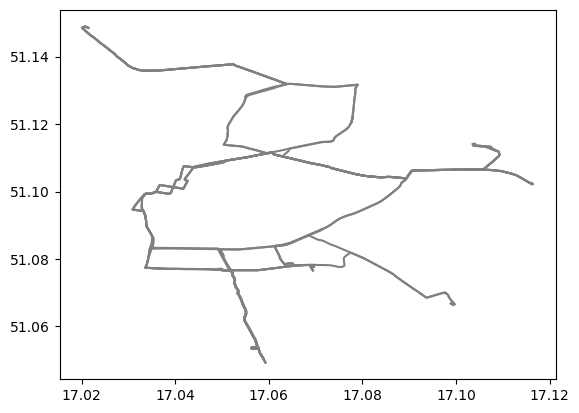

In [310]:
for i in range(len(separated_shapes)):
    plt.plot(separated_shapes[i]['shape_pt_lon'], separated_shapes[i]['shape_pt_lat'], c='grey')

In [ ]:
# time steps in frequency 5 seconds
WAIT_TIME = 1
ALL_TIME = pd.date_range(today+pd.DateOffset(hours=6), today+pd.DateOffset(hours=11), freq='5s')
dt = 1/60
STEPS = len(ALL_TIME)
BOARDING_SPEED = 30
stop_passengers_max = 200
START_SIMULATION = '6:00:00'
STOP_SIMULATION = '11:00:00'

In [ ]:
# only keep trips between 6-11, as this includes morning rush hours
mask_trip_ids = selected_stop_times[(selected_stop_times['arrival_time']>'11:00:00') | (selected_stop_times['arrival_time']<'06:00:00')]['trip_id'].unique()
in_time_stop_times = selected_stop_times[~(selected_stop_times['arrival_time']>'11:00:00') & ~(selected_stop_times['arrival_time']<'06:00:00')]
all_trip_ids = selected_stop_times['trip_id'].unique() 
selected_trip_ids = all_trip_ids[~all_trip_ids.isin(mask_trip_ids)]
selected_trip_ids = trips[(trips['trip_id'].isin(selected_trip_ids)) & (trips['service_id'] ==6)]['trip_id']

In [800]:
def save_anim(animation: FuncAnimation,name='anim3.gif',fps=30) -> None:
    animation.save(f'outputs/{name}', writer='imagemagick', fps=fps)

In [ ]:
# where stops are located
stops_position = {stops.iloc[i]['stop_id']: [stops.iloc[i]['stop_lat'], stops.iloc[i]['stop_lon']] for i in range(len(stops))}

# Simulation - functions

In [ ]:
class TransportSimulation:
    # class for simulating the transport network
    def __init__(self, trip_ids, lam=1, boarding_speed=20):
        self.trip_ids = trip_ids
        self.buses = [Bus(id, boarding_speed) for id in self.trip_ids]
        self.stop_ids = np.unique(np.concatenate([bus.stop_list for bus in self.buses])).astype(str)
        self.stops = {str(id): Stop(id, lam) for id in self.stop_ids}
        self.dt = dt # 1- minute
        self.steps = len(ALL_TIME)
        self.t = 0
        self.lam=lam
        self.bunched = 0
        self.boarding_speed = boarding_speed
    def get_buses_at_stop(self, t):
        [bus.bus_at_stop(t) for bus in self.buses]
    def start_buses(self, t):
        for b in range(len(self.buses)):
            if self.buses[b].start_index == t:
                self.buses[b].start_bus()
    def stop_buses(self, t):
        for b in range(len(self.buses)):
            if self.buses[b].position[t] == self.buses[b].relative_position[-1]:
                stop_id = str(self.buses[b].stop_list[int(self.buses[b].position[t])])
                if self.stops[stop_id].passengers[t] == 0:
                    self.buses[b].at_route = False
    def time_step(self, t):
        [self.stops[id].passengers_arrival(t) for id in self.stop_ids]
        self.start_buses(t)
        self.get_buses_at_stop(t)
        for b in range(len(self.buses)):
            bus = self.buses[b]
            #if b == 35:
            #    print(bus.at_route, bus.at_stop, bus.relative_step, bus.position[t-1])
            if bus.at_route:
                if bus.at_stop:
                    if self.buses[b].time_at_stop == 0:
                        self.buses[b].get_exits(t)
                        self.buses[b].deboarding = True
                    self.buses[b].time_at_stop += 1 
                    stop_id = str(bus.stop_list[int(bus.position[t])])
                    self.stops[stop_id].visited=1
                    self.stops[stop_id].visits += 1
                    self.buses[b].board_passengers(self.stops[stop_id], t)
                    if (self.stops[stop_id].passengers[t] == 0 or self.buses[b].is_full(t)) and self.buses[b].deboarding==False:
                        self.buses[b].load_complete = True
                    #if b == 35:
                        #print(stop_id, self.stops[stop_id].passengers[t], self.buses[b].load_complete, self.buses[b].relative_step, self.buses[b].time_at_stop)    
                    if self.buses[b].time_at_stop > 1:
                        self.buses[b].delay[t] += 1  
                    if self.buses[b].load_complete: # get buses that are done loading on the move
                        self.buses[b].time_at_stop = 0
                        self.buses[b].load_complete = False
                        overtake, self.bunched = self.buses[b].stop_before_overtake(self.buses, t, self.bunched)
                        if  overtake == False:
                            self.buses[b].advance()
                else:
                    if np.random.random() > 0.02: # random delay 5% of times
                        overtake, self.bunched = self.buses[b].stop_before_overtake(self.buses, t, self.bunched)
                        if overtake == False:
                            self.buses[b].advance()
                self.buses[b].move(t)
            self.buses[b].delay[t+1] = self.buses[b].delay[t]    
            self.buses[b].passengers[t+1] = self.buses[b].passengers[t]   
            

        self.stop_buses(t)    
    def simulate(self):
        for t in range(STEPS-1):
            #print(t)
            self.time_step(t)
            self.t = t
            #print(t, self.buses[35].position[t], self.buses[35].relative_step, self.buses[35].at_stop)
        self.colors = self.eval_colors()
    def frame(self,t, axs):
        axs.clear()
        for i in range(len(separated_shapes)):
            axs.plot(separated_shapes[i]['shape_pt_lon'], separated_shapes[i]['shape_pt_lat'], c='grey', alpha=0.3)
        #axs.set_xlim(stops['stop_lon'].min(), stops['stop_lon'].max())
        #axs.set_ylim(stops['stop_lat'].min(), stops['stop_lat'].max())
        pos_prev = np.array([(stops_position[str(bus.stop_list[int(bus.position[t])])]) for bus in self.buses])
        pos_next = np.array([(stops_position[str(bus.stop_list[int(int(bus.position[t]))])]) for bus in self.buses])
        pos_int = np.array([[np.interp(self.buses[b].position[t]%1, [0,1], [pos_prev[b][i], pos_next[b][i]]) for i in range(2)] for b in range(len(self.buses))])
        #axs.scatter(pos_prev[:,1], pos_prev[:,0])
        #axs.scatter(pos_next[:,1], pos_next[:,0])
        axs.scatter(pos_int[:,1], pos_int[:,0], color=[self.colors[int(bus.delay[t])] for bus in self.buses], alpha=1)
        axs.set_title(f"{ALL_TIME[t]}")
    def animate(self, fig):
        animation = FuncAnimation(fig, self.frame, fargs=(axs,),
                            frames=STEPS, repeat=False, interval=1000)
        return animation
    def eval_colors(self):
        self.max_delay = max([max(self.buses[i].delay) for i in range(len(self.buses))])
        no_delay = (0,0.58,0)
        delays_gb = 0.62
        if self.max_delay == 0:
            return [no_delay]
        else:
            color_step = delays_gb/self.max_delay
            delays = [(1,0.62-color_step*i,0.62-color_step*i) for i in range(int(self.max_delay))]
            return [no_delay]+delays

class Bus:
    def __init__(self, trip_id, boarding_speed=20):
        self.trip_id = trip_id
        self.stop_times = selected_stop_times[selected_stop_times['trip_id'] == trip_id]
        self.route_id = trips[trips['trip_id']== trip_id]['route_id']
        #self.relative_position = np.zeros(STEPS)
        trip = separated_stop_times[trip_id].copy()
        self.start = trip['arrival_time'].iloc[0]
        self.stop = trip['arrival_time'].iloc[-1]
        self.start_index = np.where(ALL_TIME == pd.to_datetime(self.start))[0][0]
        self.stop_index = np.where(ALL_TIME == pd.to_datetime(self.stop))[0][0]
        self.no_stops = len(trip)
        shift_fill = pd.to_datetime(self.start)+pd.offsets.Minute(-1) # shift to start of bus
        trip['arrival_time'] = pd.to_datetime(trip['arrival_time'])
        no_minutes = ((trip['arrival_time'] - trip['arrival_time'].shift(1, fill_value=shift_fill)).dt.total_seconds()/60).astype(int).to_list()
        #stops_by_minute = [[trip['stop_sequence'].to_list()[i]]*no_minutes[i] for i in range(no_stops)]
        relative_position = [trip['stop_sequence'].to_list()[i]+np.linspace(0, 1,no_minutes[i]+1)[:-1] for i in range(self.no_stops)]
        #stops_by_minute = [[trip['stop_id'].to_list()[i]]*no_minutes[i] for i in range(self.no_stops)]
        self.stop_list = trip['stop_id'].to_list()
        relative_position = [j for i in relative_position for j in i]
        #stops_by_minute = [j for i in stops_by_minute for j in i] # stop numbers
        #self.relative_position[self.start_index:self.stop_index+1] = relative_position
        self.relative_position = relative_position
        self.relative_step = 0 # current index as in relative_positions
        self.position = -1*np.ones(STEPS)
        self.at_stop = False
        self.time_at_stop = 0
        #self.end_wait_time = WAIT_TIME
        self.passengers = np.zeros(STEPS)
        self.boarding_speed = boarding_speed*dt # per dt
        self.at_route = False
        self.delay=np.zeros(STEPS)
        self.load_complete = False
        self.capacity = 140
        self.passengers_to_unboard = 0
        self.deboarding = False
    def start_bus(self):
        self.position[self.start_index] =0
        self.at_route = True

    def move(self, t):
        if self.position[t] != self.relative_position[-1]:
            self.position[t+1] = self.relative_position[self.relative_step]
        else:
            self.position[t+1] = self.position[t]
    def advance(self):
        # advance in relative position
        self.relative_step += 1
    def introduce_delay(self, time_index, delay):
        self.delay += delay
        #current_pos = self.position[time_index]
        #self.position[time_index+delay:] = self.stops_by_minute[time_index:-delay]
        #self.position[time_index:time_index+delay] = current_stop
    def bus_at_stop(self, t):
        if self.position[t] == -1:
            self.at_stop=False
        else:
            self.at_stop = np.min([self.position[t]%1, 1-self.position[t]%1]) < dt/8 # if whole number
    def board_passengers(self, stop, t):
        left_boarding_time = 1
        if self.passengers_to_unboard >0:
            unboarded_passengers = np.min([np.ceil(self.boarding_speed), self.passengers_to_unboard])
            self.passengers[t] += -unboarded_passengers
            self.passengers_to_unboard += - unboarded_passengers
            left_boarding_time = 1-unboarded_passengers/(self.boarding_speed)
        if self.passengers_to_unboard == 0:
            self.deboarding = False
            available_space = self.capacity-self.passengers[t]
            boarded_passengers = np.min([np.min([np.ceil(left_boarding_time*self.boarding_speed), stop.passengers[t]]), available_space])
            #print(available_space, boarded_passengers, stop.passengers[t])
            stop.passengers[t] = stop.passengers[t] - boarded_passengers
            self.passengers[t] += boarded_passengers
    def get_exits(self, t):
        stop_number = int(self.position[t])
        passengers_on_board = self.passengers[t]
        exits = int(np.round(self.exiting_pattern(stop_number)*passengers_on_board))
        self.passengers_to_unboard = exits
    def is_full(self, t):
        return self.passengers[t] >= self.capacity
    def exiting_pattern(self, stop_number):
        x = np.arange(0, self.no_stops)
        middle = (self.no_stops-1)/2
        #return -0.001*((stop_number-middle)**2-middle**2)
        return 0.05+np.random.random()/4
    def stop_before_overtake(self, buses, t, bunched):

        org_stop_id = str(self.stop_list[int(self.position[t])])
        for bus in buses:
            if bus.at_route:
                if bus.at_stop:
                    stop_id = str(bus.stop_list[int(bus.position[t])])
                    if stop_id == org_stop_id:
                        #print(t, org_stop_id, stop_id, "ten sam przystanek")
                        if bus.start< self.start:
                            bunched +=1
                            return True, bunched
        return False, bunched
class Stop:
    def __init__(self, stop_id, lam):
        self.stop_id = stop_id
        self.passengers = np.zeros(STEPS)
        self.dt = dt
        self.visited=0
        self.last_visit = 1
        self.total_visits = in_time_stop_times['stop_id'].value_counts()[int(stop_id)]
        self.visits = 0
        if in_time_stop_times['stop_id'].value_counts()[int(stop_id)]<5:
            self.common_stop=0
        else:
            self.common_stop=1
        self.lam = lam
    def passengers_arrival(self, t):
        lam = self.lam*self.dt
        #lam = 0
        if self.visits == self.total_visits:
            self.last_visit = 0
        self.passengers[t] = np.min([self.passengers[t-1] + np.round(self.visited*np.random.poisson(lam)*self.common_stop),stop_passengers_max])#*self.last_visit
    def passengers_boarding(self): 
        pass          

In [316]:
shape = shapes[shapes['shape_id'] == shapes_ids[2]]
#fig, axs = plt.subplots(figsize=(10,6))
all_shapes_ids = shapes['shape_id'].unique()[:10]
all_shapes_ids = shapes_ids
colors = {'145':'blue', '146':'green'}
def draw_map(axs):
    for i in range(len(all_shapes_ids)):
        shape = shapes[shapes['shape_id'] == all_shapes_ids[i]]
        axs.plot(shape['shape_pt_lon'],shape['shape_pt_lat'], lw=1, c='grey', alpha=0.7)
    return 
def draw_step(step, axs, shift):
    axs.clear()
    draw_map(axs)
    for i in range(len(trips_ids)):
        stops_ = list(stops_by_minute.values())[i]
        stop = stops_[step+shift]
        route = selected_trips['route_id'].iloc[i]
        if stop !=0:
            axs.plot(stops[stop][1], stops[stop][0], 'o', c=colors[route])
        axs.set_title(f"{all_time[step+shift]}")
#axs.set_aspect('equal', adjustable='box')

In [317]:
def animate(fig, frames, shift=0):
    animation = FuncAnimation(fig, draw_step, fargs=(axs,shift),
                            frames=frames, repeat=False, interval=1000)
    return animation

In [ ]:
# whichc stops are actually used by our buses
selected_stops = stops[stops['stop_id'].isin(selected_stop_times['stop_id'].unique())]

# Simulation

In [842]:
simulation = TransportSimulation(selected_trip_ids, lam=0.65, boarding_speed=30)
simulation.simulate()

## Bus position as number of stops visited in time

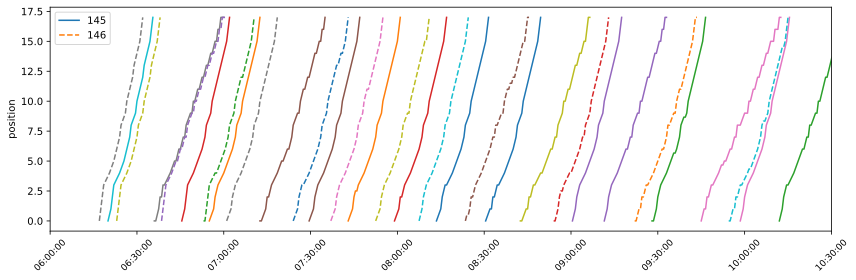

In [ ]:
# PLOTIING BUS POSITION IN TIME
patterns = ["145 - 1 - A",  "146 - 1 - A"]
common_stops = pattern_stops[0][np.isin(pattern_stops[0], pattern_stops[1])]
plot_trips = [selected_trip_ids.isin(selected_trips[selected_trips['pattern_name'] == pattern]['trip_id']) for pattern in patterns]

fig, axs = plt.subplots(figsize=(12,4))
for b in range(len(simulation.buses)):
    if plot_trips[0].iloc[b]:
        common_stop_mask = np.where(np.isin(pattern_stops[0], common_stops))[0]
        shift = common_stop_mask[0]
        bus = simulation.buses[b]
        mask = (bus.position >=common_stop_mask[0]) & (bus.position <= common_stop_mask[-1])
        axs.plot(np.arange(STEPS)[mask], -shift+bus.position[mask])
        #axs.plot(bus.position)
    if plot_trips[1].iloc[b]:
        common_stop_mask = np.where(np.isin(pattern_stops[1], common_stops))[0]
        shift = common_stop_mask[0]
        bus = simulation.buses[b]
        mask = (bus.position >=common_stop_mask[0]) & (bus.position <= common_stop_mask[-1])
        axs.plot(np.arange(STEPS)[mask], bus.position[mask]-shift, '--')
        #axs.plot(bus.position)
axs.plot([],[],label="145")
axs.plot([],[], '--', label="146")
axs.legend()
axs.set_xticks(np.arange(STEPS)[:-60:int(30/dt)], ALL_TIME[:-60:int(30/dt)].time, rotation=45, fontsize=9)
axs.set_ylabel("position")
axs.set_xlim(np.arange(STEPS)[:-60:int(30/dt)][0], np.arange(STEPS)[:-60:int(30/dt)][-1])
plt.tight_layout()
plt.savefig("poz", dpi=300)

In [541]:
patterns = ["145 - 1 - A",  "146 - 1 - A"]
pattern_stops = []
for i in range(2):
    pattern_one_index = plot_trips[i].reset_index(drop=True)[plot_trips[i].reset_index(drop=True)].index[0]
    pattern_one_id = plot_trips[i].index[pattern_one_index]
    print(pattern_one_id)
    pattern_stops.append(np.array(simulation.buses[int(pattern_one_index)].stop_list))
common_stops = pattern_stops[0][np.isin(pattern_stops[0], pattern_stops[1])]
shift = np.where(np.isin(pattern_stops[1], common_stops))[0][0]-np.where(np.isin(pattern_stops[0], common_stops))[0][0]


33015
33423


In [662]:
patterned_trips = selected_trip_ids[selected_trip_ids.isin(selected_trips[selected_trips['pattern_name'].isin(patterns)]['trip_id'])].values
buses = np.array(simulation.buses)[np.array([np.isin(bus.trip_id,patterned_trips) for bus in simulation.buses])]

In [ ]:
buses = simulation.buses[bus.trip_id in patterns for bus in simulation.buses]
for bus in simulation.buses:
    if bus.trip_id in patterns:
        [simulation.buses[i].delay[-1]>0 for i in range(len(simulation.buses))]

## How does passenger arrival speed and passenger boarding speed impact trip delays?

In [766]:
lams = np.linspace(0.3, 1.6, 10)
N = 10
delays30 = np.zeros((len(lams), N))
delays15 = np.zeros((len(lams), N))
delays5 = np.zeros((len(lams), N))
bunched = np.zeros((len(lams), N))
stop_pass = np.zeros((len(lams), N)) 
bus_pass = np.zeros((len(lams), N)) 
for i in range(len(lams)):
    lam = lams[i]
    for j in range(N): 
        simulation = TransportSimulation(selected_trip_ids, lam=lam, boarding_speed=35)
        simulation.simulate()
        delays30[i, j] = np.mean([simulation.buses[i].delay[-1]>30 for i in range(len(simulation.buses))])
        delays5[i, j] = np.mean([simulation.buses[i].delay[-1]>5 for i in range(len(simulation.buses))])
        delays15[i, j] = np.mean([simulation.buses[i].delay[-1]>15 for i in range(len(simulation.buses))])
        bus_pass[i, j] = np.nanmean([np.nanmean(simulation.buses[i].passengers[simulation.buses[i].passengers>0]) for i in range(len(simulation.buses))])
        stop_pass[i, j] = np.mean([np.mean(stop.passengers) for stop in simulation.stops.values()])
        bunched[i, j] = simulation.bunched

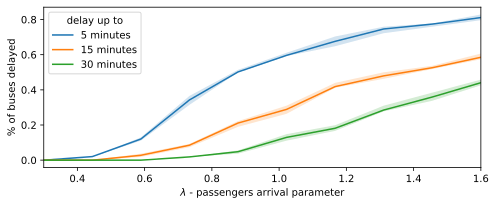

In [767]:
fig, axs = plt.subplots(figsize=(7,3))
axs.plot(lams, np.mean(delays5, axis=1), label="5 minutes")
axs.fill_between(lams, np.percentile(delays5, 25, axis=1),np.percentile(delays5, 75, axis=1), alpha=0.2)
axs.plot(lams, np.mean(delays15, axis=1), label="15 minutes")
axs.fill_between(lams, np.percentile(delays15, 25, axis=1),np.percentile(delays15, 75, axis=1), alpha=0.2)
axs.plot(lams, np.mean(delays30, axis=1), label="30 minutes")
axs.fill_between(lams, np.percentile(delays30, 25, axis=1),np.percentile(delays30, 75, axis=1), alpha=0.2)

axs.set_xlim(lams[0], lams[-1])
axs.legend(title="delay up to")
axs.set_xlabel("$\lambda$ - passengers arrival parameter")
axs.set_ylabel("% of buses delayed")
plt.tight_layout()
plt.savefig("lam1", dpi=200)    

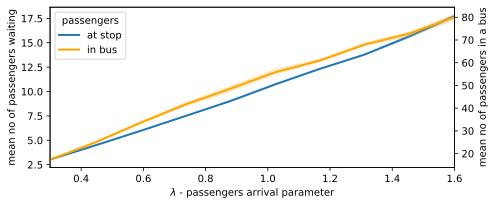

In [768]:
fig, axs = plt.subplots(figsize=(7,3))
axs.plot(lams, np.mean(stop_pass, axis=1), lw=2, label="at stop")
axs.fill_between(lams, np.percentile(stop_pass, 25, axis=1),np.percentile(stop_pass, 75, axis=1), alpha=0.2)
ax_ = axs.twinx()
ax_.plot(lams, np.mean(bus_pass, axis=1), c='orange', lw=2, label="in bus")
ax_.fill_between(lams, np.percentile(bus_pass, 25, axis=1),np.percentile(bus_pass, 75, axis=1), alpha=0.2, color="orange")
axs.plot([], [], c='orange', lw=2, label="in bus")
axs.set_xlim(lams[0], lams[-1])

axs.legend(title="passengers")
axs.set_xlabel("$\lambda$ - passengers arrival parameter")
axs.set_ylabel("mean no of passengers waiting")
ax_.set_ylabel("mean no of passengers in a bus")
plt.tight_layout()

plt.savefig("lam2", dpi=200)    


In [770]:
speeds = np.linspace(15,50, 10).astype(int)
N = 10
delays30 = np.zeros((len(lams), N))
delays15 = np.zeros((len(lams), N))
delays5 = np.zeros((len(lams), N))
bunched = np.zeros((len(lams), N))
stop_pass = np.zeros((len(lams), N)) 
bus_pass = np.zeros((len(lams), N)) 
for i in range(len(speeds)):
    boarding_speed = speeds[i]
    for j in range(N): 
        simulation = TransportSimulation(selected_trip_ids, boarding_speed=boarding_speed, lam=0.6)
        simulation.simulate()
        delays30[i, j] = np.mean([simulation.buses[i].delay[-1]>30 for i in range(len(simulation.buses))])
        delays5[i, j] = np.mean([simulation.buses[i].delay[-1]>5 for i in range(len(simulation.buses))])
        delays15[i, j] = np.mean([simulation.buses[i].delay[-1]>15 for i in range(len(simulation.buses))])
        bus_pass[i, j] = np.nanmean([np.nanmean(simulation.buses[i].passengers[simulation.buses[i].passengers>0]) for i in range(len(simulation.buses))])
        stop_pass[i, j] = np.mean([np.mean(stop.passengers) for stop in simulation.stops.values()])
        bunched[i, j] = simulation.bunched

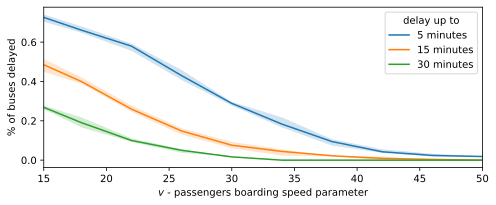

In [771]:
fig, axs = plt.subplots(figsize=(7,3))

axs.plot(speeds, np.mean(delays5, axis=1), label="5 minutes")
axs.fill_between(speeds, np.percentile(delays5, 25, axis=1),np.percentile(delays5, 75, axis=1), alpha=0.2)
axs.plot(speeds, np.mean(delays15, axis=1), label="15 minutes")
axs.fill_between(speeds, np.percentile(delays15, 25, axis=1),np.percentile(delays15, 75, axis=1), alpha=0.2)
axs.plot(speeds, np.mean(delays30, axis=1), label="30 minutes")
axs.fill_between(speeds, np.percentile(delays30, 25, axis=1),np.percentile(delays30, 75, axis=1), alpha=0.2)

axs.set_xlim(speeds[0], speeds[-1])

axs.legend(title="delay up to")
axs.set_xlabel("$\lambda$ - passengers arrival parameter")
axs.set_ylabel("% of buses delayed")
axs.set_xlabel("$v$ - passengers boarding speed parameter")
plt.tight_layout()

plt.savefig("s1", dpi=200)    


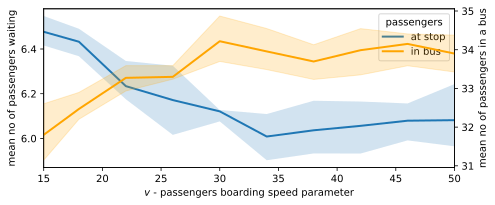

In [773]:
fig, axs = plt.subplots(figsize=(7,3))
axs.plot(speeds, np.mean(stop_pass, axis=1), lw=2, label="at stop")
axs.fill_between(speeds, np.percentile(stop_pass, 25, axis=1),np.percentile(stop_pass, 75, axis=1), alpha=0.2)
ax_ = axs.twinx()
ax_.plot(speeds, np.mean(bus_pass, axis=1), c='orange', lw=2, label="in bus")
ax_.fill_between(speeds, np.percentile(bus_pass, 25, axis=1),np.percentile(bus_pass, 75, axis=1), alpha=0.2, color="orange")

axs.plot([], [], c='orange', lw=2, label="in bus")
axs.set_xlim(speeds[0], speeds[-1])

axs.legend(title="passengers")
axs.set_xlabel("$v$ - passengers boarding speed parameter")
axs.set_ylabel("mean no of passengers waiting")
ax_.set_ylabel("mean no of passengers in a bus")
plt.tight_layout()

plt.savefig("s2", dpi=200)    


In [ ]:
unique, counts = np.unique(np.concatenate([bus.stop_list for bus in simulation.buses]), return_counts=True)
#print(np.asarray((unique, counts)).T)

## How many passengers are waiting at the stops?

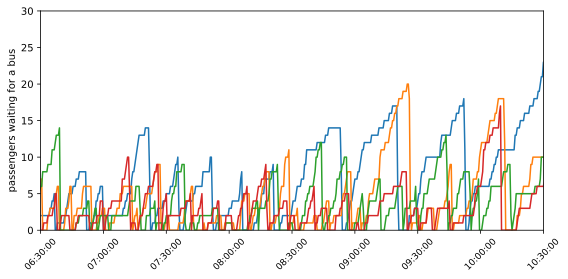

In [822]:
fig, axs = plt.subplots(figsize=(8,4))
k=0
for i in simulation.stop_ids:  
    if k>6 and k<11:
        axs.plot(simulation.stops[i].passengers)
    k += 1
axs.set_xticks(np.arange(STEPS)[60:-60:int(30/dt)], ALL_TIME[60:-60:int(30/dt)].time, rotation=45, fontsize=9)
axs.set_xlim(np.arange(STEPS)[60:-60:int(30/dt)][0], np.arange(STEPS)[60:-60:int(30/dt)][-1])
axs.set_ylim(0,30)
axs.set_ylabel("passengers waiting for a bus")
plt.tight_layout()
plt.savefig("stops", dpi=200)    

In [ ]:
shape1 = 867033
shape2 =  865125

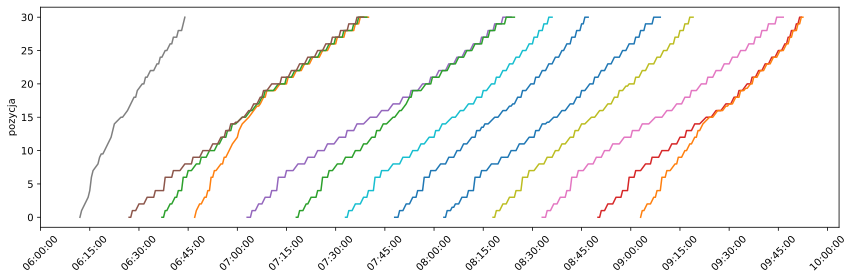

In [699]:
pattern = '145 - 1 - A'
plot_trips = selected_trip_ids.isin(selected_trips[selected_trips['pattern_name'] == pattern]['trip_id'])

fig, axs = plt.subplots(figsize=(12,4))
for b in range(len(simulation.buses)):
    if plot_trips.iloc[b]:
        bus = simulation.buses[b]
        axs.plot(np.arange(STEPS)[(bus.position != -1) & (bus.position < 30.5)], bus.position[(bus.position != -1) & (bus.position < 30.5)])
        #axs.plot(bus.position)
axs.set_xticks(np.arange(STEPS)[::30], ALL_TIME[::30].time, rotation=45)
axs.set_ylabel("pozycja")
plt.tight_layout()
plt.savefig("opozn12", dpi=200)

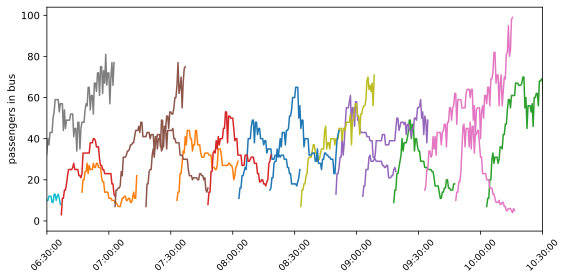

In [838]:
pattern = '145 - 1 - A'
plot_trips = selected_trip_ids.isin(selected_trips[selected_trips['pattern_name'] == pattern]['trip_id'])
fig, axs = plt.subplots(figsize=(8,4))
for b in range(len(simulation.buses)):
    if plot_trips.iloc[b]:
        bus = simulation.buses[b]  
        axs.plot(np.arange(STEPS)[(bus.position != -1) & (bus.position < 30.5)], bus.passengers[(bus.position != -1) & (bus.position < 30.5)])
axs.set_xticks(np.arange(STEPS)[60:-60:int(30/dt)], ALL_TIME[60:-60:int(30/dt)].time, rotation=45, fontsize=9)
axs.set_xlim(np.arange(STEPS)[60:-60:int(30/dt)][0], np.arange(STEPS)[60:-60:int(30/dt)][-1])
axs.set_ylabel("passengers in bus")
plt.tight_layout()
plt.savefig("bus_pass", dpi=200)

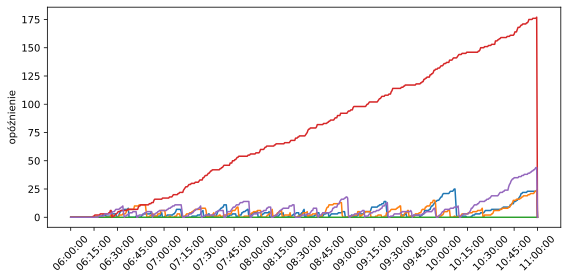

In [ ]:
fig, axs = plt.subplots(figsize=(8,4))
ids = list(simulation.stops.keys())
for b in range(5):
    id = ids[b]
    bus = simulation.stops[id]  
    axs.plot(bus.passengers)
axs.set_xticks(np.arange(STEPS)[::30], ALL_TIME[::30].time, rotation=45)
axs.set_ylabel("opóźnienie")
plt.tight_layout()

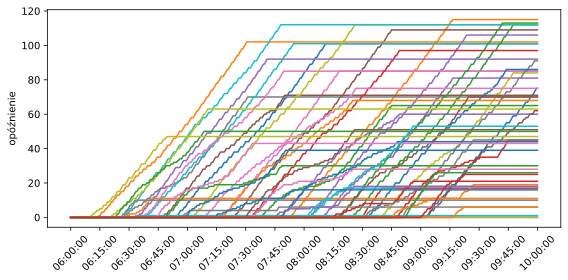

In [ ]:
fig, axs = plt.subplots(figsize=(8,4))
for b in range(len(simulation.buses)):
        bus = simulation.buses[b]  
        axs.plot(bus.delay)
axs.set_xticks(np.arange(STEPS)[::30], ALL_TIME[::30].time, rotation=45)
axs.set_ylabel("opóźnienie")
plt.tight_layout()

# Animating bus positions

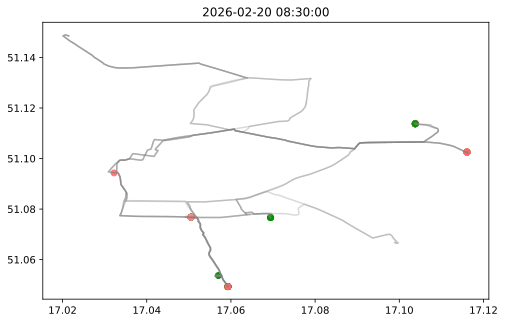

In [ ]:
fig, axs = plt.subplots(figsize=(8,5), dpi=100)
simulation.frame(1800, axs)
plt.savefig("gif", dpi=300)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.PillowWriter'>


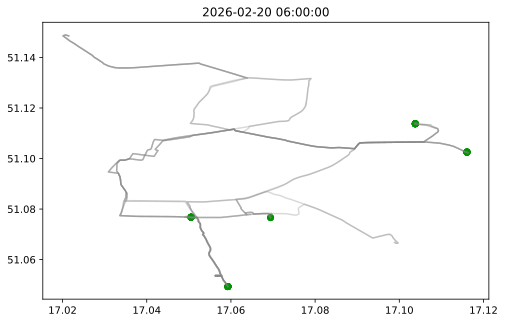

In [844]:
fig,axs = plt.subplots(figsize=(8,5), dpi=100)
anim  = simulation.animate(fig)
save_anim(anim, fps=35)

# Bus routes in city network
Why these buses were selected? - Common route in city center, as shown below.

In [ ]:
shapes_ids_map = np.array([separated_shapes[i]['shape_id'].iloc[0] for i in range(len(separated_shapes))])
for i in range(len(separated_shapes)):
    if shapes_ids_map[i] in [shape1, shape2]:
        print(i)

In [ ]:
common_shape = pd.merge(separated_shapes[5][["shape_pt_lat",	"shape_pt_lon"]], separated_shapes[6][["shape_pt_lat","shape_pt_lon"]])
shapes_unq = shapes['shape_id'].unique()


In [ ]:
fig,axs = plt.subplots(figsize=(8,5))
labs = [146, 145]
j=0
k=5
for i in range(len(shapes_unq)):
    id = shapes_unq[i]
    shape = shapes[shapes['shape_id']==id]
    axs.plot(shape['shape_pt_lon'], shape['shape_pt_lat'], label="", lw=0.3, c='grey', alpha=0.05)
    #if shapes_ids_map[i] in [shape1, shape2]:
    if id in [shape1, shape2]:
        axs.plot(shape['shape_pt_lon'], shape['shape_pt_lat'], label=labs[j], lw=2)
        j+=1
axs.plot(common_shape.iloc[k:]['shape_pt_lon'], common_shape.iloc[k:]['shape_pt_lat'], label="shared route", lw=4)
axs.legend()
#plt.savefig('trasy.jpg', dpi=300)